In [175]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression , Ridge , Lasso
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.metrics import r2_score


In [176]:
X , y = make_regression(
    n_samples=200,
    n_features=1,
    noise=20,
    random_state=42)


In [177]:
X_b = np.c_[np.ones((200,1)),X]

In [178]:
def total_cost(X_b , y , theta):
    m=len(y)
    y_pred = X_b @ theta
    error=y_pred - y
    cost=( 1 / (2 * m))* np.sum(error ** 2)
    return cost
    

In [179]:
def gradient_descent(X_b , y , theta , alpha , n_iterations):
    m=len(y)
    cost_history=[]
    for i in range(n_iterations):
        y_pred= X_b @ theta
        error=y_pred - y
        gradients = (1/m) * X_b.T @ error
        theta = theta - alpha* gradients
        cost_history.append(total_cost(X_b,y,theta))
    return theta , cost_history


In [180]:
theta=np.zeros(2)
alpha=0.01
n_iterations=1000
theta_final , cost_history = gradient_descent(X_b , y , theta , alpha , n_iterations)
print("Intercept:" , theta_final[0])
print("Slope:" , theta_final[1])

Intercept: 2.8534801538040444
Slope: 86.97977088857964


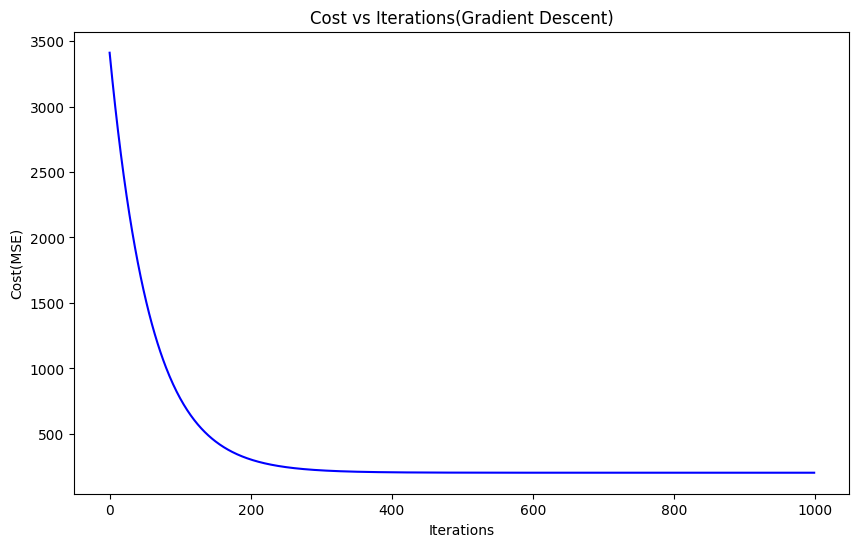

In [181]:
# plot cost curve
plt.figure(figsize=(10,6))
plt.plot(range(n_iterations),cost_history,color="blue")
plt.title("Cost vs Iterations(Gradient Descent)")
plt.xlabel("Iterations")
plt.ylabel("Cost(MSE)")
plt.savefig("plots/01_cost_curve.png")

In [182]:

y_pred_scratch = X_b @ theta_final
ss_res = np.sum((y - y_pred_scratch) ** 2)
ss_tot = np.sum((y - np.mean(y)) ** 2)
r2_scratch = 1 - (ss_res / ss_tot)
sk_model = LinearRegression()
sk_model.fit(X, y)
r2_sklearn = sk_model.score(X, y)
print(f'Scratch  -> Intercept: {theta_final[0]:.4f}, Slope: {theta_final[1]:.4f}, R2: {r2_scratch:.4f}')
print(f'Sklearn  -> Intercept: {sk_model.intercept_:.4f}, Slope: {sk_model.coef_[0]:.4f}, R2: {r2_sklearn:.4f}')
X_line = np.array([[X.min()], [X.max()]])
X_line_b = np.c_[np.ones((2, 1)), X_line]



Scratch  -> Intercept: 2.8535, Slope: 86.9798, R2: 0.9414
Sklearn  -> Intercept: 2.8570, Slope: 86.9955, R2: 0.9414


In [183]:
plt.figure(figsize=(10, 6))
plt.scatter(X, y, color='gray', alpha=0.5, label='Data')
plt.plot(X_line, X_line_b @ theta_final, color='blue', label=f'Scratch (R2={r2_scratch:.3f})')
plt.plot(X_line, sk_model.predict(X_line), color='red', linestyle='--', label=f'Sklearn (R2={r2_sklearn:.3f})')
plt.title('Best Fit Line - Scratch vs Sklearn')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.savefig('plots/02_best_fit.png')
plt.close()
print('Plot 2 saved.')

Plot 2 saved.


In [184]:
X2 , Y2 = make_regression(n_samples=100, n_features=1, noise=15, random_state=42)
X2_train, X2_test, Y2_train, Y2_test = train_test_split(X2, Y2, test_size=0.2, random_state=42)
degrees = [1,4,15]
colors = ["red", "green" , "blue"]
X_plot = np.linspace(X2.min(),X2.max() , 300).reshape(-1,1)
plt.figure(figsize=(10,6))
plt.scatter(X2, Y2, color="gray", alpha=0.5 , label="data")
for deg , col in zip(degrees , colors):
    model = make_pipeline(PolynomialFeatures(deg) , LinearRegression())
    model.fit(X2_train , Y2_train)
    train_r2 = model.score(X2_train , Y2_train)
    test_r2 = model.score(X2_test , Y2_test)
    print(f"Degree {deg:2d} -> Train_r2:{train_r2:.4f} -> Test_r2:{test_r2:.4f}")
    plt.plot(X_plot , model.predict(X_plot) , color=col, label=f"Degree {deg} (Test r2={test_r2:.3f})")
plt.title("Polynomial Degree Comparison - Underfit / fit / Overfit",fontweight="bold")
plt.xlabel("X")
plt.ylabel("Y")
plt.legend()
plt.savefig("plots/03_poly_comparison")
plt.close()

Degree  1 -> Train_r2:0.9116 -> Test_r2:0.8742
Degree  4 -> Train_r2:0.9118 -> Test_r2:0.8735
Degree 15 -> Train_r2:0.9164 -> Test_r2:0.8871


In [185]:
poly=PolynomialFeatures(degree=15)
X2_train_poly = poly.fit_transform(X2_train)
X2_test_poly = poly.fit(X2_test)
models = {
    "No reg" : LinearRegression(),
    "Ridge(1.0)" : Ridge(alpha=1.0),
    "Lasso(0.01)" : Lasso(alpha=0.01 , max_iter = 10000)
}
colors_reg = ["red" , "blue" , "green"]
plt.figure(figsize=(10,6))
for (name,model) , col in zip(models.items() , colors_reg):
    model.fit(X2_train_poly, Y2_train)
    plt.plot(model.coef_, label=name, color=col , marker="o" , markersize=3)
plt.title("Regularization - Coefficient Values (Degree - 15 Polynomial)")
plt.xlabel("Coefficient Index")
plt.ylabel("Coefficient Values")
plt.legend()
plt.savefig("plots/04_regularization.png")
plt.close()
print("Plot 4 saved")

c:\Users\dell\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.523e+03, tolerance: 1.485e+01
  model = cd_fast.enet_coordinate_descent(


Plot 4 saved


In [186]:
# polynomial regression
X= 6* np.random.rand(200,1) - 3
Y= 0.8 * X ** 2 + 0.9 * X + 2 + np.random.rand(200,1)


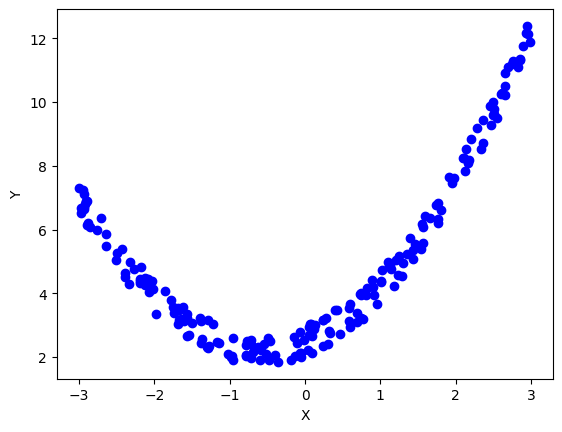

In [187]:
plt.scatter(X,Y,color="blue")
plt.xlabel("X")
plt.ylabel("Y")
plt.show()

In [188]:
# train test split
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,random_state=2)

In [189]:
lr=LinearRegression()

In [190]:
lr.fit(X_train,Y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [191]:
y_pred=lr.predict(X_test)
r2_score(Y_test,y_pred)

0.25394170072205946

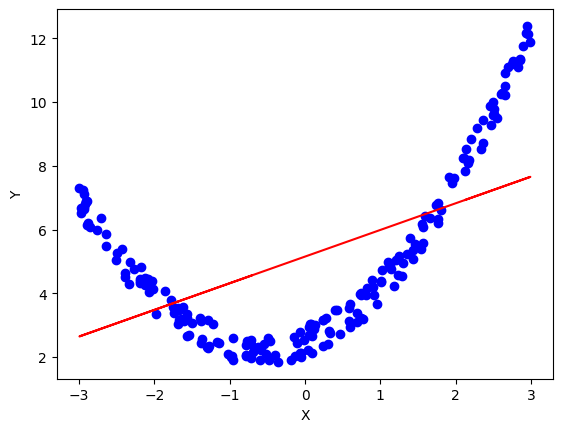

<Figure size 640x480 with 0 Axes>

In [192]:
plt.plot(X_train,lr.predict(X_train),color="red")
plt.scatter(X,Y,color="blue")
plt.xlabel("X")
plt.ylabel("Y")
plt.show()
plt.savefig("plots/06_underfitting.png")

In [193]:
# applying polynomial linear regression (degree=2)
poly=PolynomialFeatures(degree=2)

X_train_trans=poly.fit_transform(X_train)
X_test_trans=poly.transform(X_test)
print(X_train[0])
print(X_train_trans[0])


[2.12781935]
[1.         2.12781935 4.5276152 ]


In [194]:
lr=LinearRegression()
lr.fit(X_train_trans,Y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [195]:
y_pred=lr.predict(X_test_trans)

In [196]:
r2_score(Y_test,y_pred)

0.9861975780524873

In [197]:
print(lr.coef_)
print(lr.intercept_)

[[0.         0.89614426 0.79867311]]
[2.51307241]


In [198]:
X_new=np.linspace(-3,3,200).reshape(200,1)
X_new_poly=poly.transform(X_new)
Y_new=lr.predict(X_new_poly)


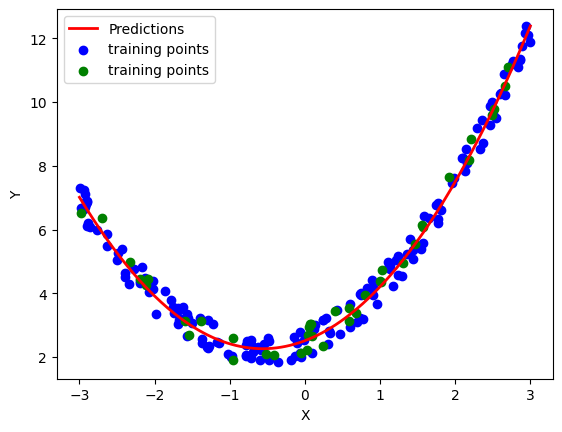

<Figure size 640x480 with 0 Axes>

In [199]:
plt.plot(X_new,Y_new,color="red",linewidth=2,label="Predictions")
plt.scatter(X_train,Y_train,color="blue",label="training points")
plt.scatter(X_test,Y_test,color="green",label="training points")
plt.xlabel("X")
plt.ylabel("Y")
plt.legend()
plt.show()
plt.savefig("plots/05_curve_fit(degree=2)")